# 逻辑回归

逻辑回归是一种用于二分类的统计方法，也就是说，它用于预测某个事件发生或不发生的概率。它属于广义线性模型的一种，通常在因变量是二元变量或类别变量时使用。

在逻辑回归中，因变量是二元的（即只能取两个值中的一个，通常为 0 或 1），而自变量既可以是连续变量，也可以是类别变量。逻辑回归的目标是通过估计在给定自变量取值时因变量为 1 的概率，来刻画自变量与因变量之间的关系。

逻辑回归模型使用逻辑函数（也称为 sigmoid 函数）将自变量的输入值映射到 0 到 1 之间，这个值表示因变量为 1 的概率。逻辑函数定义如下：

css
Copy code
p = 1 / (1 + e^(-z))
其中，p 是因变量为 1 的预测概率，e 是自然对数的底数，z 是自变量的线性组合。

逻辑回归模型通过估计自变量系数的取值，使得在给定模型的前提下观测到当前数据的似然最大化。这通常通过最大似然估计或梯度下降优化来完成。

模型训练完成后，可以将新数据的自变量取值输入逻辑函数，得到因变量为 1 的预测概率，从而对新样本进行预测。然后，模型可以根据用户设定的概率阈值，将新观测分类为 1 或 0。


## 代码
下面给出一个使用梯度下降优化的实现示例：

In [2]:
import numpy as np

class LogisticRegression:
    
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        # initialize weights and bias to zeros
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # gradient descent optimization
        for i in range(self.n_iters):
            # calculate predicted probabilities and cost
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(z)
            cost = (-1 / n_samples) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
            
            # calculate gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
    def predict(self, X):
        # calculate predicted probabilities
        z = np.dot(X, self.weights) + self.bias
        y_pred = self._sigmoid(z)
        # convert probabilities to binary predictions
        return np.round(y_pred).astype(int)
    
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))


### 测试

In [3]:
# create sample dataset
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
y = np.array([0, 0, 1, 1, 1])

# initialize logistic regression model
lr = LogisticRegression()

# train model on sample dataset
lr.fit(X, y)

# make predictions on new data
X_new = np.array([[6, 7], [7, 8]])
y_pred = lr.predict(X_new)

print(y_pred)  # [1, 1]



[1 1]


### 改进
下面是一些可以对代码进行的改进：

1. 添加正则化：正则化有助于防止过拟合，并提升模型的泛化性能。你可以在代价函数中加入 L1 或 L2 正则化，并通过一个超参数来调节正则化强度。下面是一个在代码中加入 L2 正则化的示例：

2. 使用更复杂的优化算法：梯度下降是一种简单且有效的优化算法，但对于大规模或复杂数据集，它不一定是最高效或最准确的选择。你可以尝试使用更复杂的算法，例如随机梯度下降（SGD）、mini-batch SGD 或 Adam，这些方法通常收敛更快，也更容易找到更优解。下面是一个使用 mini-batch SGD 的示例：

In [9]:
import numpy as np

class LogisticRegression:
    
    def __init__(self, learning_rate=0.01, n_iters=1000, regularization='l2', reg_strength=0.1, batch_size=32):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.regularization = regularization
        self.reg_strength = reg_strength
        self.batch_size = batch_size
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        n_batches = n_samples // self.batch_size
        for i in range(self.n_iters):
            batch_indices = np.random.choice(n_samples, self.batch_size)
            X_batch = X[batch_indices]
            y_batch = y[batch_indices]
            z = np.dot(X_batch, self.weights) + self.bias
            y_pred = self._sigmoid(z)
            cost = (-1 / self.batch_size) * np.sum(y_batch * np.log(y_pred) + (1 - y_batch) * np.log(1 - y_pred))
            if self.regularization == 'l2':
                reg_cost = (self.reg_strength / (2 * n_samples)) * np.sum(self.weights ** 2)
                cost += reg_cost
            elif self.regularization == 'l1':
                reg_cost = (self.reg_strength / (2 * n_samples)) * np.sum(np.abs(self.weights))
                cost += reg_cost
            dw = (1 / self.batch_size) * np.dot(X_batch.T, (y_pred - y_batch))
            db = (1 / self.batch_size) * np.sum(y_pred - y_batch)
            if self.regularization == 'l2':
                dw += (self.reg_strength / n_samples) * self.weights
            elif self.regularization == 'l1':
                dw += (self.reg_strength / n_samples) * np.sign(self.weights)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        y_pred = self._sigmoid(z)
        return np.round(y_pred).astype(int)
    
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))


该实现包含以下改进：

1. 正则化：你可以将 regularization 参数设置为 'l1' 或 'l2'，从而选择 L1 或 L2 正则化，并通过 reg_strength 参数调整正则化强度。

2. Mini-batch 随机梯度下降：模型使用 mini-batch SGD（而不是普通梯度下降）来更新权重和偏置，这样通常能够更快收敛并找到更优解。


### 测试

In [10]:
# create sample dataset
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
y = np.array([0, 0, 1, 1, 1])

# initialize logistic regression model
lr = LogisticRegression(learning_rate=0.01, n_iters=1000, regularization='l2', reg_strength=0.1, batch_size=2)

# train model on sample dataset
lr.fit(X, y)

# make predictions on new data
X_new = np.array([[6, 7], [7, 8]])
y_pred = lr.predict(X_new)

print(y_pred)  # [1, 1]


[1 1]


## 可视化

逻辑回归较难可视化，因为它本质上是一个高维问题。不过，对于二维数据集，我们可以可视化逻辑回归模型的决策边界。

下面给出一个示例，说明如何使用 matplotlib 库在二维数据集上可视化 `LogisticRegression` 类的决策边界：

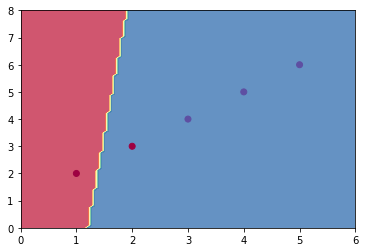

In [11]:
import matplotlib.pyplot as plt

# create 2D dataset
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])
y = np.array([0, 0, 1, 1, 1])

# initialize logistic regression model
lr = LogisticRegression(learning_rate=0.01, n_iters=1000, regularization='l2', reg_strength=0.1, batch_size=2)

# train model on dataset
lr.fit(X, y)

# plot decision boundary
x1 = np.linspace(0, 6, 100)
x2 = np.linspace(0, 8, 100)
xx, yy = np.meshgrid(x1, x2)
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

# plot data points
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.Spectral)

plt.show()